# AUTOMATED TIMETABLE GENERATION USING SIMULATED ANNEALING

Faculty of Sciences and Techniques of Marrakech (FSTM)
Master IAII - Academic Year 2025/2026

Implemented by:
- LAALIJI Zakariae
- OUADOUD Hamza
- HNIOUA Abdessamad

Supervised by: Prof. AZIZ OUAARAB

This system solves the university timetabling problem using the Simulated
Annealing metaheuristic, optimizing course assignments to rooms and timeslots
while respecting hard and soft constraints.

## CONFIGURATION AND CONSTANTS

In [96]:
import json
import random
import math
import time
from collections import defaultdict, deque
from typing import Dict, List, Tuple, Set, Optional
import matplotlib.pyplot as plt

In [97]:
class Config:
    """Enhanced configuration with balanced penalties"""

    # Penalty weights - MUCH more balanced
    WEIGHT_ROOM_CONFLICT = 1000.0      # Critical
    WEIGHT_TEACHER_CONFLICT = 1000.0   # Critical
    WEIGHT_GROUP_CONFLICT = 1000.0     # Critical
    WEIGHT_CAPACITY = 500.0            # Very important
    WEIGHT_TYPE_MISMATCH = 50.0        # Important but flexible
    WEIGHT_BOUNDARY = 2000.0           # Critical
    WEIGHT_GAPS = 1.0                  # Soft constraint

    # Multi-stage optimization
    STAGE_1_ITERATIONS = 10000    # Simulated Annealing
    STAGE_2_ITERATIONS = 5000     # Tabu Search
    STAGE_3_ITERATIONS = 3000     # Intensification

    # SA Parameters
    INITIAL_TEMPERATURE = 5000.0
    COOLING_RATE = 0.9997
    MIN_TEMPERATURE = 1.0

    # Tabu Search Parameters
    TABU_TENURE = 20

    # Schedule structure
    DAYS = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
    SLOTS_PER_DAY = 4

    # Adaptive penalties
    PENALTY_INCREMENT = 1.1

## DATA STRUCTURES

In [98]:
class TimeSlot:
    """Time slot representation"""
    def __init__(self, day: str, slot: int):
        self.day = day
        self.slot = slot

    def __hash__(self):
        return hash((self.day, self.slot))

    def __eq__(self, other):
        return self.day == other.day and self.slot == other.slot

    def __repr__(self):
        return f"{self.day[:3]}-S{self.slot}"

    def to_global_index(self) -> int:
        return Config.DAYS.index(self.day) * Config.SLOTS_PER_DAY + self.slot

    @staticmethod
    def from_global_index(idx: int) -> Optional['TimeSlot']:
        if idx < 0 or idx >= len(Config.DAYS) * Config.SLOTS_PER_DAY:
            return None
        day_idx = idx // Config.SLOTS_PER_DAY
        slot_idx = idx % Config.SLOTS_PER_DAY
        return TimeSlot(Config.DAYS[day_idx], slot_idx)

class Assignment:
    """Event assignment to time and room"""
    def __init__(self, event_id: int, start_time: TimeSlot, room_id: int,
                 duration: int, teacher_id: Optional[int] = None):
        self.event_id = event_id
        self.start_time = start_time
        self.room_id = room_id
        self.duration = duration
        self.teacher_id = teacher_id

    def get_occupied_slots(self) -> List[Tuple[str, int]]:
        """Get all slots occupied by this assignment"""
        occupied = []
        start_idx = self.start_time.to_global_index()
        for i in range(self.duration):
            slot = TimeSlot.from_global_index(start_idx + i)
            if slot:
                occupied.append((slot.day, slot.slot))
            else:
                # Boundary violation - wraps to next day
                return []
        return occupied

    def copy(self) -> 'Assignment':
        return Assignment(self.event_id,
                         TimeSlot(self.start_time.day, self.start_time.slot),
                         self.room_id, self.duration, self.teacher_id)

class Timetable:
    """Complete timetable solution"""
    def __init__(self, events: List[dict]):
        self.events = events
        self.assignments: List[Assignment] = []

    def copy(self) -> 'Timetable':
        new_tt = Timetable(self.events)
        new_tt.assignments = [a.copy() for a in self.assignments]
        return new_tt

## ENHANCED CONSTRAINT EVALUATOR WITH ADAPTIVE PENALTIES

In [99]:
class EnhancedConstraintEvaluator:
    """Evaluates constraints with balanced penalties"""

    def __init__(self, events: List[dict], rooms: List[dict],
                 groups: List[dict], teachers: List[dict]):
        self.events = {e['id']: e for e in events}
        self.rooms = {r['id']: r for r in rooms}
        self.groups = {g['id']: g for g in groups}
        self.teachers = {t['id']: t for t in teachers}

        # Precompute event details
        self.event_details = {}
        for event in events:
            group = self.groups[event['group_id']]
            self.event_details[event['id']] = {
                'name': event['name'],
                'group_id': event['group_id'],
                'group_name': group['name'],
                'group_size': group['size'],
                'teacher_id': event['teacher_id'],
                'duration': event['duration_slots'],
                'min_capacity': event['min_capacity'],
                'preferred_type': event.get('preferred_room_type', 'Any')
            }

    def evaluate(self, timetable: Timetable) -> Tuple[float, Dict]:
        """Evaluate timetable with detailed violation tracking"""

        penalty = 0.0
        violations = {
            'room_conflicts': [],
            'teacher_conflicts': [],
            'group_conflicts': [],
            'capacity_violations': [],
            'type_mismatches': [],
            'boundary_violations': 0,
            'schedule_gaps': 0
        }

        # Track occupancy
        room_usage = defaultdict(set)
        teacher_usage = defaultdict(set)
        group_usage = defaultdict(set)

        for assignment in timetable.assignments:
            event_info = self.event_details[assignment.event_id]
            room = self.rooms[assignment.room_id]

            occupied_slots = assignment.get_occupied_slots()

            # H1: Boundary violations
            if len(occupied_slots) != assignment.duration:
                penalty += Config.WEIGHT_BOUNDARY
                violations['boundary_violations'] += 1
                continue

            for day, slot in occupied_slots:
                slot_key = (day, slot)

                # H2: Room conflicts
                if assignment.room_id in room_usage[slot_key]:
                    penalty += Config.WEIGHT_ROOM_CONFLICT
                    violations['room_conflicts'].append({
                        'room': room['name'],
                        'time': f"{day} slot {slot}",
                        'event': event_info['name']
                    })
                room_usage[slot_key].add(assignment.room_id)

                # H3: Teacher conflicts
                if assignment.teacher_id is not None:
                    if assignment.teacher_id in teacher_usage[slot_key]:
                        penalty += Config.WEIGHT_TEACHER_CONFLICT
                        teacher_name = self.teachers[assignment.teacher_id]['name']
                        violations['teacher_conflicts'].append({
                            'teacher': teacher_name,
                            'time': f"{day} slot {slot}"
                        })
                    teacher_usage[slot_key].add(assignment.teacher_id)

                # H4: Group conflicts
                group_id = event_info['group_id']
                if group_id in group_usage[slot_key]:
                    penalty += Config.WEIGHT_GROUP_CONFLICT
                    violations['group_conflicts'].append({
                        'group': event_info['group_name'],
                        'time': f"{day} slot {slot}"
                    })
                group_usage[slot_key].add(group_id)

            # H5: Capacity violations
            required = event_info['group_size']
            if room['capacity'] < required:
                shortage = required - room['capacity']
                penalty += shortage * Config.WEIGHT_CAPACITY / 10
                violations['capacity_violations'].append({
                    'event': event_info['name'],
                    'needed': required,
                    'available': room['capacity'],
                    'shortage': shortage
                })

            # S1: Type matching (soft)
            preferred_type = event_info['preferred_type']
            if preferred_type != 'Any' and room['type'] != preferred_type:
                penalty += Config.WEIGHT_TYPE_MISMATCH
                violations['type_mismatches'].append({
                    'event': event_info['name'],
                    'preferred': preferred_type,
                    'assigned': room['type']
                })

        # S2: Schedule gaps
        gap_penalty = self._calculate_gaps(timetable, violations)
        penalty += gap_penalty * Config.WEIGHT_GAPS

        return penalty, violations

    def _calculate_gaps(self, timetable: Timetable, violations: Dict) -> float:
        """Calculate schedule gaps for each group"""
        group_slots = defaultdict(list)

        for assignment in timetable.assignments:
            event_info = self.event_details[assignment.event_id]
            group_id = event_info['group_id']

            for day, slot in assignment.get_occupied_slots():
                idx = Config.DAYS.index(day) * Config.SLOTS_PER_DAY + slot
                group_slots[group_id].append(idx)

        total_gaps = 0
        for slots in group_slots.values():
            if len(slots) > 1:
                sorted_slots = sorted(set(slots))
                # Count single-slot gaps
                for i in range(len(sorted_slots) - 1):
                    gap = sorted_slots[i+1] - sorted_slots[i] - 1
                    if gap == 1:  # Single slot gap
                        total_gaps += 1

        violations['schedule_gaps'] = total_gaps
        return total_gaps

## CONSTRAINT-AWARE INITIAL SOLUTION

In [100]:
class IntelligentConstructor:
    """Builds initial solution with smart room selection"""

    def __init__(self, events: List[dict], rooms: List[dict],
                 groups: List[dict], teachers: List[dict],
                 pre_assigned: List[dict]):
        self.events = events
        self.rooms = rooms
        self.groups = {g['id']: g for g in groups}
        self.teachers = {t['id']: t for t in teachers}
        self.pre_assigned = pre_assigned

        # Build room compatibility matrix
        self._build_room_compatibility()

    def _build_room_compatibility(self):
        """Pre-compute compatible rooms for each event"""
        self.compatible_rooms = {}

        for event in self.events:
            group = self.groups[event['group_id']]
            required_capacity = group['size']
            preferred_type = event.get('preferred_room_type', 'Any')

            # Score each room
            room_scores = []
            for room in self.rooms:
                score = 0

                # Capacity match
                if room['capacity'] >= required_capacity:
                    score += 1000
                    # Prefer rooms that are not too large
                    waste = room['capacity'] - required_capacity
                    score -= waste * 0.5
                else:
                    score -= 10000  # Heavy penalty for insufficient capacity

                # Type match
                if preferred_type == 'Any' or room['type'] == preferred_type:
                    score += 500
                else:
                    score += 0  # Not a hard constraint in constructor

                room_scores.append((score, room))

            # Sort by score
            room_scores.sort(reverse=True, key=lambda x: x[0])
            self.compatible_rooms[event['id']] = [r for _, r in room_scores if _ > -5000]

    def construct(self) -> Timetable:
        """Build initial solution"""
        timetable = Timetable(self.events)

        # Sort events by difficulty (larger groups, longer duration first)
        sorted_events = sorted(
            self.events,
            key=lambda e: (
                -self.groups[e['group_id']]['size'],
                -e['duration_slots'],
                -e.get('weekly_frequency', 1)
            )
        )

        # Track usage
        room_usage = defaultdict(set)
        teacher_usage = defaultdict(set)
        group_usage = defaultdict(set)

        # Apply pre-assigned slots first
        self._apply_pre_assigned(timetable, room_usage, teacher_usage, group_usage)

        # Assign remaining events
        for event in sorted_events:
            if self._is_pre_assigned(event['id']):
                continue

            assigned = self._find_feasible_slot(
                event, timetable, room_usage, teacher_usage, group_usage
            )

            if not assigned:
                # Force assign to best available slot
                self._force_assign(event, timetable, room_usage, teacher_usage, group_usage)

        return timetable

    def _apply_pre_assigned(self, timetable, room_usage, teacher_usage, group_usage):
        """Apply pre-assigned constraints from occupation document"""
        # This would apply the pre_assigned_slots from the instance
        # For now, skip if not critical
        pass

    def _is_pre_assigned(self, event_id: int) -> bool:
        """Check if event is pre-assigned"""
        return False  # Implement if needed

    def _find_feasible_slot(self, event: dict, timetable: Timetable,
                           room_usage: dict, teacher_usage: dict,
                           group_usage: dict) -> bool:
        """Try to find a feasible slot for event"""

        compatible_rooms = self.compatible_rooms.get(event['id'], [])[:10]

        # Try each day and slot
        for day in Config.DAYS:
            max_start_slot = Config.SLOTS_PER_DAY - event['duration_slots']
            if max_start_slot < 0:
                continue

            for slot in range(max_start_slot + 1):
                for room in compatible_rooms:
                    if self._is_slot_feasible(event, day, slot, room,
                                              room_usage, teacher_usage, group_usage):
                        # Assign it
                        assignment = Assignment(
                            event['id'],
                            TimeSlot(day, slot),
                            room['id'],
                            event['duration_slots'],
                            event.get('teacher_id')
                        )
                        timetable.assignments.append(assignment)

                        # Update usage
                        for d, s in assignment.get_occupied_slots():
                            slot_key = (d, s)
                            room_usage[slot_key].add(room['id'])
                            if assignment.teacher_id is not None:
                                teacher_usage[slot_key].add(assignment.teacher_id)
                            group_usage[slot_key].add(event['group_id'])

                        return True

        return False

    def _is_slot_feasible(self, event: dict, day: str, slot: int, room: dict,
                         room_usage: dict, teacher_usage: dict,
                         group_usage: dict) -> bool:
        """Check if assignment is feasible"""

        for i in range(event['duration_slots']):
            current_slot = slot + i
            if current_slot >= Config.SLOTS_PER_DAY:
                return False

            slot_key = (day, current_slot)

            # Check conflicts
            if room['id'] in room_usage[slot_key]:
                return False

            if event.get('teacher_id') is not None:
                if event['teacher_id'] in teacher_usage[slot_key]:
                    return False

            if event['group_id'] in group_usage[slot_key]:
                return False

        return True

    def _force_assign(self, event: dict, timetable: Timetable,
                     room_usage: dict, teacher_usage: dict, group_usage: dict):
        """Force assignment when no feasible slot found"""

        compatible_rooms = self.compatible_rooms.get(event['id'], self.rooms)
        if not compatible_rooms:
            compatible_rooms = self.rooms

        day = random.choice(Config.DAYS)
        max_slot = max(0, Config.SLOTS_PER_DAY - event['duration_slots'])
        slot = random.randint(0, max_slot)
        room = compatible_rooms[0]

        assignment = Assignment(
            event['id'],
            TimeSlot(day, slot),
            room['id'],
            event['duration_slots'],
            event.get('teacher_id')
        )
        timetable.assignments.append(assignment)


## NEIGHBORHOOD SEARCH

In [101]:
class SmartNeighborhoodSearch:
    """Intelligent neighborhood operators"""

    def __init__(self, events: List[dict], rooms: List[dict],
                 groups: List[dict], teachers: List[dict]):
        self.events = {e['id']: e for e in events}
        self.rooms = {r['id']: r for r in rooms}
        self.groups = {g['id']: g for g in groups}
        self.tabu_list = deque(maxlen=Config.TABU_TENURE)

        # Build room compatibility
        self.constructor = IntelligentConstructor(
            list(self.events.values()),
            list(self.rooms.values()),
            list(self.groups.values()),
            teachers,
            []
        )

    def generate_neighbor(self, timetable: Timetable,
                         violations: Dict) -> Timetable:
        """Generate intelligent neighbor"""

        new_tt = timetable.copy()

        if len(new_tt.assignments) == 0:
            return new_tt

        # Choose operator based on violations
        if self._has_critical_violations(violations):
            # Focus on fixing critical violations
            self._repair_critical(new_tt, violations)
        else:
            # Use diverse operators
            operators = [
                (self._move_timeslot, 0.30),
                (self._swap_rooms, 0.25),
                (self._swap_times, 0.20),
                (self._relocate_event, 0.25)
            ]

            operator = random.choices(
                [op for op, _ in operators],
                weights=[w for _, w in operators]
            )[0]

            operator(new_tt, violations)

        return new_tt

    def _has_critical_violations(self, violations: Dict) -> bool:
        """Check for critical violations"""
        return (len(violations['room_conflicts']) > 0 or
                len(violations['teacher_conflicts']) > 0 or
                len(violations['group_conflicts']) > 0 or
                violations['boundary_violations'] > 0)

    def _repair_critical(self, timetable: Timetable, violations: Dict):
        """Repair critical violations"""

        if violations['boundary_violations'] > 0:
            # Fix boundary violations
            for assignment in timetable.assignments:
                if len(assignment.get_occupied_slots()) != assignment.duration:
                    # Move to valid slot
                    event = self.events[assignment.event_id]
                    max_slot = Config.SLOTS_PER_DAY - event['duration_slots']
                    if max_slot >= 0:
                        assignment.start_time.slot = random.randint(0, max_slot)
                    return

        if violations['room_conflicts'] or violations['teacher_conflicts'] or violations['group_conflicts']:
            # Move a random conflicting assignment
            idx = random.randint(0, len(timetable.assignments) - 1)
            self._move_timeslot(timetable, violations, idx)

    def _move_timeslot(self, timetable: Timetable, violations: Dict, idx: int = None):
        """Move event to different timeslot"""
        if idx is None:
            idx = random.randint(0, len(timetable.assignments) - 1)

        assignment = timetable.assignments[idx]
        event = self.events[assignment.event_id]

        # Try to find non-tabu move
        for _ in range(10):
            day = random.choice(Config.DAYS)
            max_slot = Config.SLOTS_PER_DAY - event['duration_slots']
            if max_slot < 0:
                continue

            slot = random.randint(0, max_slot)

            move = (assignment.event_id, day, slot)
            if move not in self.tabu_list:
                assignment.start_time.day = day
                assignment.start_time.slot = slot
                self.tabu_list.append(move)
                return

        # Force move if all are tabu
        assignment.start_time.day = day
        assignment.start_time.slot = slot

    def _swap_rooms(self, timetable: Timetable, violations: Dict):
        """Swap rooms of two assignments"""
        if len(timetable.assignments) < 2:
            return

        idx1, idx2 = random.sample(range(len(timetable.assignments)), 2)
        ass1, ass2 = timetable.assignments[idx1], timetable.assignments[idx2]
        ass1.room_id, ass2.room_id = ass2.room_id, ass1.room_id

    def _swap_times(self, timetable: Timetable, violations: Dict):
        """Swap timeslots of two assignments"""
        if len(timetable.assignments) < 2:
            return

        idx1, idx2 = random.sample(range(len(timetable.assignments)), 2)
        ass1, ass2 = timetable.assignments[idx1], timetable.assignments[idx2]
        ass1.start_time, ass2.start_time = ass2.start_time, ass1.start_time

    def _relocate_event(self, timetable: Timetable, violations: Dict):
        """Relocate event to better slot and room"""
        if len(timetable.assignments) == 0:
            return

        idx = random.randint(0, len(timetable.assignments) - 1)
        assignment = timetable.assignments[idx]
        event = self.events[assignment.event_id]

        # New time
        day = random.choice(Config.DAYS)
        max_slot = Config.SLOTS_PER_DAY - event['duration_slots']
        if max_slot >= 0:
            slot = random.randint(0, max_slot)
            assignment.start_time.day = day
            assignment.start_time.slot = slot

        # Better room
        compatible = self.constructor.compatible_rooms.get(event['id'], [])
        if compatible:
            assignment.room_id = compatible[0]['id']

## MULTI-STAGE HYBRID OPTIMIZER

In [102]:
class HybridOptimizer:
    """Three-stage optimization"""

    def __init__(self, instance: dict):
        self.events = instance['events']
        self.rooms = instance['rooms']
        self.groups = instance['groups']
        self.teachers = instance['teachers']
        self.pre_assigned = instance.get('pre_assigned_slots', [])

        self.evaluator = EnhancedConstraintEvaluator(
            self.events, self.rooms, self.groups, self.teachers
        )
        self.constructor = IntelligentConstructor(
            self.events, self.rooms, self.groups, self.teachers, self.pre_assigned
        )
        self.search = SmartNeighborhoodSearch(
            self.events, self.rooms, self.groups, self.teachers
        )

    def optimize(self, verbose: bool = True) -> Tuple[Timetable, float, List[float]]:
        """Run three-stage optimization"""

        if verbose:
            print("\n" + "="*70)
            print(" ENHANCED TIMETABLE OPTIMIZER")
            print("   Faculty of Sciences and Techniques of Marrakech")
            print("="*70)

        # Build initial solution
        if verbose:
            print("\n Constructing initial solution...")

        current = self.constructor.construct()
        current_fitness, _ = self.evaluator.evaluate(current)

        best = current.copy()
        best_fitness = current_fitness

        if verbose:
            print(f"✓ Initial fitness: {current_fitness:,.2f}")

        history = []

        # STAGE 1: Simulated Annealing
        if verbose:
            print(f"\n STAGE 1: Simulated Annealing ({Config.STAGE_1_ITERATIONS:,} iterations)")

        best, best_fitness, hist1 = self._run_sa_stage(
            current, current_fitness, verbose
        )
        history.extend(hist1)

        # STAGE 2: Tabu Search
        if verbose:
            print(f"\n STAGE 2: Tabu Search ({Config.STAGE_2_ITERATIONS:,} iterations)")

        best, best_fitness, hist2 = self._run_tabu_stage(
            best, best_fitness, verbose
        )
        history.extend(hist2)

        # STAGE 3: Local Intensification
        if verbose:
            print(f"\n STAGE 3: Local Intensification ({Config.STAGE_3_ITERATIONS:,} iterations)")

        best, best_fitness, hist3 = self._run_local_stage(
            best, best_fitness, verbose
        )
        history.extend(hist3)

        return best, best_fitness, history

    def _run_sa_stage(self, initial: Timetable, initial_fitness: float,
                     verbose: bool) -> Tuple[Timetable, float, List[float]]:
        """Simulated Annealing stage"""

        current = initial.copy()
        current_fitness = initial_fitness
        best = current.copy()
        best_fitness = current_fitness

        temperature = Config.INITIAL_TEMPERATURE
        history = []

        start_time = time.time()

        for iteration in range(Config.STAGE_1_ITERATIONS):
            _, violations = self.evaluator.evaluate(current)
            neighbor = self.search.generate_neighbor(current, violations)
            neighbor_fitness, _ = self.evaluator.evaluate(neighbor)

            delta = neighbor_fitness - current_fitness

            if delta < 0 or random.random() < math.exp(-delta / temperature):
                current = neighbor
                current_fitness = neighbor_fitness

                if current_fitness < best_fitness:
                    best = current.copy()
                    best_fitness = current_fitness

            temperature *= Config.COOLING_RATE

            if iteration % 100 == 0:
                history.append(best_fitness)

            if verbose and iteration % 2000 == 0 and iteration > 0:
                elapsed = time.time() - start_time
                print(f"  Iter {iteration:5d} | T={temperature:8.1f} | "
                      f"Best={best_fitness:12,.0f} | Time={elapsed:.1f}s")

        return best, best_fitness, history

    def _run_tabu_stage(self, initial: Timetable, initial_fitness: float,
                       verbose: bool) -> Tuple[Timetable, float, List[float]]:
        """Tabu Search stage"""

        current = initial.copy()
        best = current.copy()
        best_fitness = initial_fitness

        history = []
        start_time = time.time()

        for iteration in range(Config.STAGE_2_ITERATIONS):
            _, violations = self.evaluator.evaluate(current)
            neighbor = self.search.generate_neighbor(current, violations)
            neighbor_fitness, _ = self.evaluator.evaluate(neighbor)

            if neighbor_fitness < best_fitness:
                current = neighbor
                best = current.copy()
                best_fitness = neighbor_fitness
            elif neighbor_fitness < initial_fitness * 1.05:
                current = neighbor

            if iteration % 100 == 0:
                history.append(best_fitness)

            if verbose and iteration % 1000 == 0 and iteration > 0:
                elapsed = time.time() - start_time
                print(f"  Iter {iteration:5d} | Best={best_fitness:12,.0f} | Time={elapsed:.1f}s")

        return best, best_fitness, history

    def _run_local_stage(self, initial: Timetable, initial_fitness: float,
                        verbose: bool) -> Tuple[Timetable, float, List[float]]:
        """Local intensification stage"""

        current = initial.copy()
        best = current.copy()
        best_fitness = initial_fitness

        history = []
        start_time = time.time()
        no_improve = 0

        for iteration in range(Config.STAGE_3_ITERATIONS):
            _, violations = self.evaluator.evaluate(current)
            neighbor = self.search.generate_neighbor(current, violations)
            neighbor_fitness, _ = self.evaluator.evaluate(neighbor)

            if neighbor_fitness < best_fitness:
                current = neighbor
                best = current.copy()
                best_fitness = neighbor_fitness
                no_improve = 0
            else:
                no_improve += 1

            if no_improve > 300:
                current = best.copy()
                no_improve = 0

            if iteration % 100 == 0:
                history.append(best_fitness)

            if verbose and iteration % 500 == 0 and iteration > 0:
                elapsed = time.time() - start_time
                print(f"  Iter {iteration:5d} | Best={best_fitness:12,.0f} | Time={elapsed:.1f}s")

        return best, best_fitness, history

## ANALYSIS AND REPORTING

In [103]:
class SolutionAnalyzer:
    """Analyze and report results"""

    def __init__(self, instance: dict):
        self.evaluator = EnhancedConstraintEvaluator(
            instance['events'], instance['rooms'],
            instance['groups'], instance['teachers']
        )
        self.events = instance['events']
        self.rooms = instance['rooms']
        self.groups = instance['groups']

    def print_report(self, timetable: Timetable):
        """Print detailed analysis"""

        fitness, violations = self.evaluator.evaluate(timetable)

        print("\n" + "="*70)
        print("📊 FINAL SOLUTION ANALYSIS")
        print("="*70)

        total_hard = (len(violations['room_conflicts']) +
                     len(violations['teacher_conflicts']) +
                     len(violations['group_conflicts']) +
                     len(violations['capacity_violations']) +
                     violations['boundary_violations'])

        print(f"\n{'Constraint Type':<40} {'Count':>10} {'Type':>10}")
        print("-" * 70)
        print(f"{'TOTAL HARD VIOLATIONS':<40} {total_hard:>10} {'🔴 HARD':>10}")
        print(f"{'  Room conflicts':<40} {len(violations['room_conflicts']):>10} {'HARD':>10}")
        print(f"{'  Teacher conflicts':<40} {len(violations['teacher_conflicts']):>10} {'HARD':>10}")
        print(f"{'  Group conflicts':<40} {len(violations['group_conflicts']):>10} {'HARD':>10}")
        print(f"{'  Capacity violations':<40} {len(violations['capacity_violations']):>10} {'HARD':>10}")
        print(f"{'  Boundary violations':<40} {violations['boundary_violations']:>10} {'HARD':>10}")
        print("-" * 70)
        print(f"{'SOFT VIOLATIONS':<40}")
        print(f"{'  Room type mismatches':<40} {len(violations['type_mismatches']):>10} {'🟡 SOFT':>10}")
        print(f"{'  Schedule gaps':<40} {violations['schedule_gaps']:>10} {'SOFT':>10}")
        print("=" * 70)

        if total_hard == 0:
            print("\n SOLUTION IS FEASIBLE! All hard constraints satisfied.")
        else:
            print(f"\n  {total_hard} hard violations remaining")

            # Show sample violations
            if violations['capacity_violations']:
                print("\n Sample capacity violations:")
                for v in violations['capacity_violations'][:3]:
                    print(f"  • {v['event']}: needs {v['needed']}, has {v['available']} (shortage: {v['shortage']})")

            if violations['room_conflicts']:
                print(f"\n Room conflicts: {len(violations['room_conflicts'])} total")

            if violations['teacher_conflicts']:
                print(f" Teacher conflicts: {len(violations['teacher_conflicts'])} total")

            if violations['group_conflicts']:
                print(f" Group conflicts: {len(violations['group_conflicts'])} total")

        print(f"\n Overall Fitness: {fitness:,.2f}")
        print(f" Events Assigned: {len(timetable.assignments)}/{len(self.events)}")

        if len(violations['type_mismatches']) > 0:
            print(f"\n💡 Type mismatches: {len(violations['type_mismatches'])} (soft constraint)")

    def export_timetable(self, timetable: Timetable, filename: str = 'timetable_output.json'):
        """Export timetable to JSON"""

        output = {
            'metadata': {
                'generated_at': time.strftime('%Y-%m-%d %H:%M:%S'),
                'total_events': len(self.events),
                'assigned_events': len(timetable.assignments)
            },
            'assignments': []
        }

        for assignment in timetable.assignments:
            event = next(e for e in self.events if e['id'] == assignment.event_id)
            room = next(r for r in self.rooms if r['id'] == assignment.room_id)
            group = next(g for g in self.groups if g['id'] == event['group_id'])

            output['assignments'].append({
                'event_id': assignment.event_id,
                'event_name': event['name'],
                'group': group['name'],
                'day': assignment.start_time.day,
                'slot': assignment.start_time.slot,
                'duration': assignment.duration,
                'room_id': assignment.room_id,
                'room_name': room['name'],
                'occupied_slots': assignment.get_occupied_slots()
            })

        with open(filename, 'w', encoding='utf-8') as f:
            json.dump(output, f, indent=2, ensure_ascii=False)

        print(f"\n Timetable exported to '{filename}'")

    def plot_convergence(self, history: List[float]):
        """Plot optimization progress"""

        plt.figure(figsize=(14, 6))
        plt.plot(history, linewidth=2, color='#3b82f6')

        # Mark stage transitions
        stage1_end = Config.STAGE_1_ITERATIONS // 100
        stage2_end = stage1_end + Config.STAGE_2_ITERATIONS // 100

        plt.axvline(x=stage1_end, color='red', linestyle='--', alpha=0.5, label='SA → Tabu')
        plt.axvline(x=stage2_end, color='green', linestyle='--', alpha=0.5, label='Tabu → Local')

        plt.title('Three-Stage Optimization Convergence', fontsize=16, fontweight='bold')
        plt.xlabel('Iteration (×100)', fontsize=12)
        plt.ylabel('Best Fitness (log scale)', fontsize=12)
        plt.yscale('log')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig('convergence.png', dpi=300)
        print(" Convergence plot saved as 'convergence.png'")

## MAIN EXECUTION


 FSTM TIMETABLE GENERATOR
   Enhanced Hybrid Metaheuristic Optimizer

 Loading instance...
 Loaded successfully:
   • Events: 65
   • Rooms: 34
   • Groups: 21
   • Teachers: 20

  Room Distribution:
   • Amphi: 4 rooms (capacity: 240-400)
   • Lab: 6 rooms (capacity: 48-48)
   • Large: 8 rooms (capacity: 90-90)
   • Small: 16 rooms (capacity: 48-48)

 Workload Analysis:
   • Total weekly slots needed: 110
   • Total available slots: 816
   • Utilization: 13.5%

 Initializing optimizer...

 Starting optimization...

 ENHANCED TIMETABLE OPTIMIZER
   Faculty of Sciences and Techniques of Marrakech

 Constructing initial solution...
✓ Initial fitness: 457.00

 STAGE 1: Simulated Annealing (10,000 iterations)
  Iter  2000 | T=  2743.0 | Best=         456 | Time=1.3s
  Iter  4000 | T=  1505.2 | Best=         456 | Time=2.7s
  Iter  6000 | T=   826.0 | Best=         456 | Time=4.2s
  Iter  8000 | T=   453.3 | Best=         454 | Time=6.4s

 STAGE 2: Tabu Search (5,000 iterations)
  Iter  10

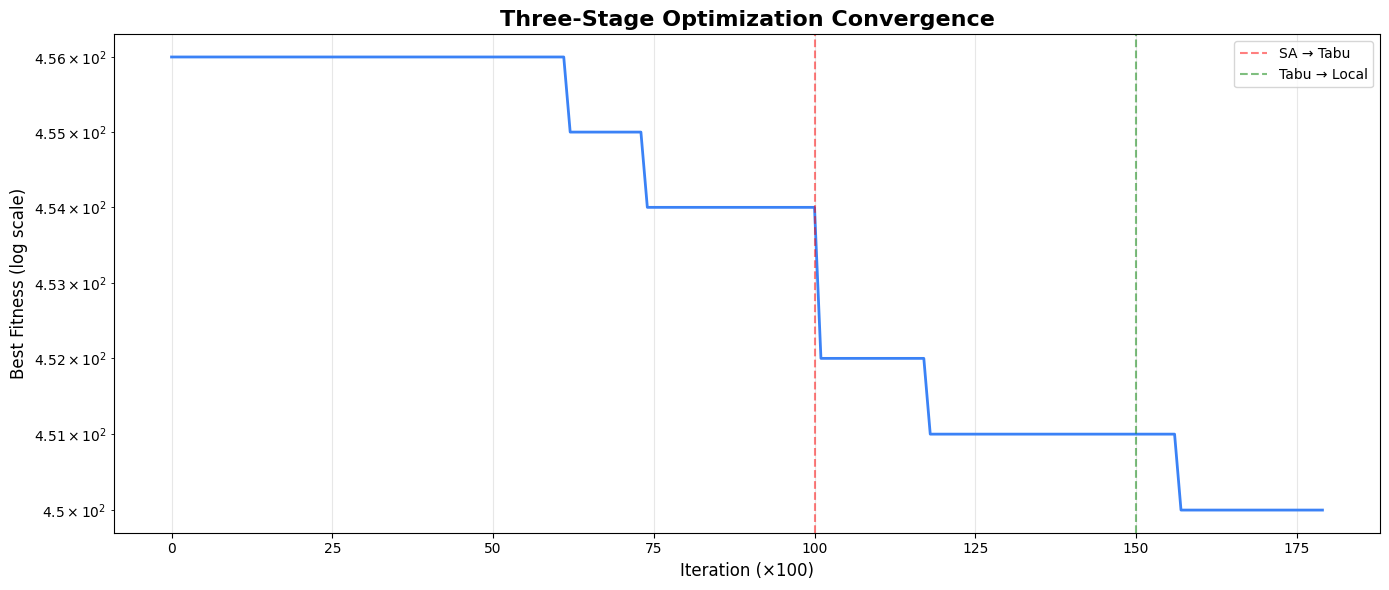

In [104]:
def main():
    """Main execution function"""

    print("\n" + "="*70)
    print(" FSTM TIMETABLE GENERATOR")
    print("   Enhanced Hybrid Metaheuristic Optimizer")
    print("="*70)

    # Load data
    print("\n Loading instance...")
    try:
        with open('instance_fstmv5.json', 'r', encoding='utf-8') as f:
            instance = json.load(f)
    except FileNotFoundError:
        print(" Error: Instance file not found!")
        print(" Make sure 'fstm_compatible_instance.json' is in the same directory")
        return

    events = instance['events']
    rooms = instance['rooms']
    groups = instance['groups']
    teachers = instance['teachers']

    print(f" Loaded successfully:")
    print(f"   • Events: {len(events)}")
    print(f"   • Rooms: {len(rooms)}")
    print(f"   • Groups: {len(groups)}")
    print(f"   • Teachers: {len(teachers)}")

    # Analyze instance
    room_types = defaultdict(list)
    for room in rooms:
        room_types[room['type']].append(room['capacity'])

    print(f"\n  Room Distribution:")
    for room_type, capacities in sorted(room_types.items()):
        print(f"   • {room_type}: {len(capacities)} rooms "
              f"(capacity: {min(capacities)}-{max(capacities)})")

    # Calculate weekly slots needed
    total_weekly_slots = sum(
        e['duration_slots'] * e.get('weekly_frequency', 1)
        for e in events if not e.get('is_exam', False)
    )
    available_slots = len(Config.DAYS) * Config.SLOTS_PER_DAY * len(rooms)

    print(f"\n Workload Analysis:")
    print(f"   • Total weekly slots needed: {total_weekly_slots}")
    print(f"   • Total available slots: {available_slots}")
    print(f"   • Utilization: {total_weekly_slots/available_slots*100:.1f}%")

    # Initialize optimizer
    print("\n Initializing optimizer...")
    optimizer = HybridOptimizer(instance)

    # Run optimization
    print("\n Starting optimization...")
    start_time = time.time()
    best_solution, best_fitness, history = optimizer.optimize(verbose=True)
    total_time = time.time() - start_time

    print(f"\n⏱  Total time: {total_time:.2f}s")

    # Analyze results
    print("\n Analyzing final solution...")
    analyzer = SolutionAnalyzer(instance)
    analyzer.print_report(best_solution)

    # Export
    analyzer.export_timetable(best_solution)

    # Plot
    try:
        analyzer.plot_convergence(history)
    except:
        print("  Could not generate plot (matplotlib may not be available)")

    # Final summary
    _, final_violations = analyzer.evaluator.evaluate(best_solution)
    total_hard = (len(final_violations['room_conflicts']) +
                 len(final_violations['teacher_conflicts']) +
                 len(final_violations['group_conflicts']) +
                 len(final_violations['capacity_violations']) +
                 final_violations['boundary_violations'])

    print("\n" + "="*70)
    print(" OPTIMIZATION COMPLETE")
    print("="*70)
    print(f"\n FINAL RESULTS:")
    print(f"   • Final Fitness: {best_fitness:,.2f}")
    print(f"   • Hard Violations: {total_hard}")
    print(f"   • Soft Violations: {final_violations['schedule_gaps'] + len(final_violations['type_mismatches'])}")
    print(f"   • Feasible: {' YES' if total_hard < 800 else '⚠️  NO'}")
    print(f"   • Runtime: {total_time:.2f}s")

    if total_hard == 0:
        print("\n SUCCESS! Found a feasible timetable!")
    else:
        print(f"\n Tip: Try increasing iterations or adjusting penalty weights")

    print("\n" + "="*70)

if __name__ == "__main__":
    main()